In [1]:
import os
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Setup Kaggle & Download Data
# Install & setup Kaggle
from google.colab import files
import os

print("Upload file kaggle.json:")
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset
!kaggle datasets download -d nalaprogroup/clean-data-project2-v2
!unzip -q clean-data-project2-v2.zip -d data_project2

print("Dataset berhasil didownload!")

Upload file kaggle.json:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/nalaprogroup/clean-data-project2-v2
License(s): CC0-1.0
100% 3.82M/3.82M [00:00<00:00, 210MB/s]

Dataset berhasil didownload!


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# 1. Load data sesuai path
df_train = pd.read_json('/content/data_project2/train_text_clean.json')
df_dev = pd.read_json('/content/data_project2/dev_text_clean.json')
df_test = pd.read_json('/content/data_project2/test_text_clean.json')

# 2. Hitung Word Count (Jumlah Kata)
df_train['article_wc'] = df_train['clean_article'].apply(lambda x: len(str(x).split()))
df_train['summary_wc'] = df_train['clean_summary'].apply(lambda x: len(str(x).split()))

# 3. Hitung Rasio Kompresi (Poin dari tutor!)
df_train['compression_ratio'] = df_train['summary_wc'] / df_train['article_wc']

print(f"Data Berhasil Dimuat! Total Train: {len(df_train)} baris")
display(df_train[['article_wc', 'summary_wc', 'compression_ratio']].describe())

Data Berhasil Dimuat! Total Train: 5000 baris


,article_wc,summary_wc,compression_ratio
count,5000.000000,5000.000000,5000.000000
mean,188.774600,26.969600,0.180498
std,117.285884,6.161093,0.105448
min,8.000000,11.000000,0.014351
25%,116.000000,24.000000,0.114544
50%,157.000000,27.000000,0.161290
75%,226.000000,30.000000,0.223910
max,1742.000000,74.000000,3.375000


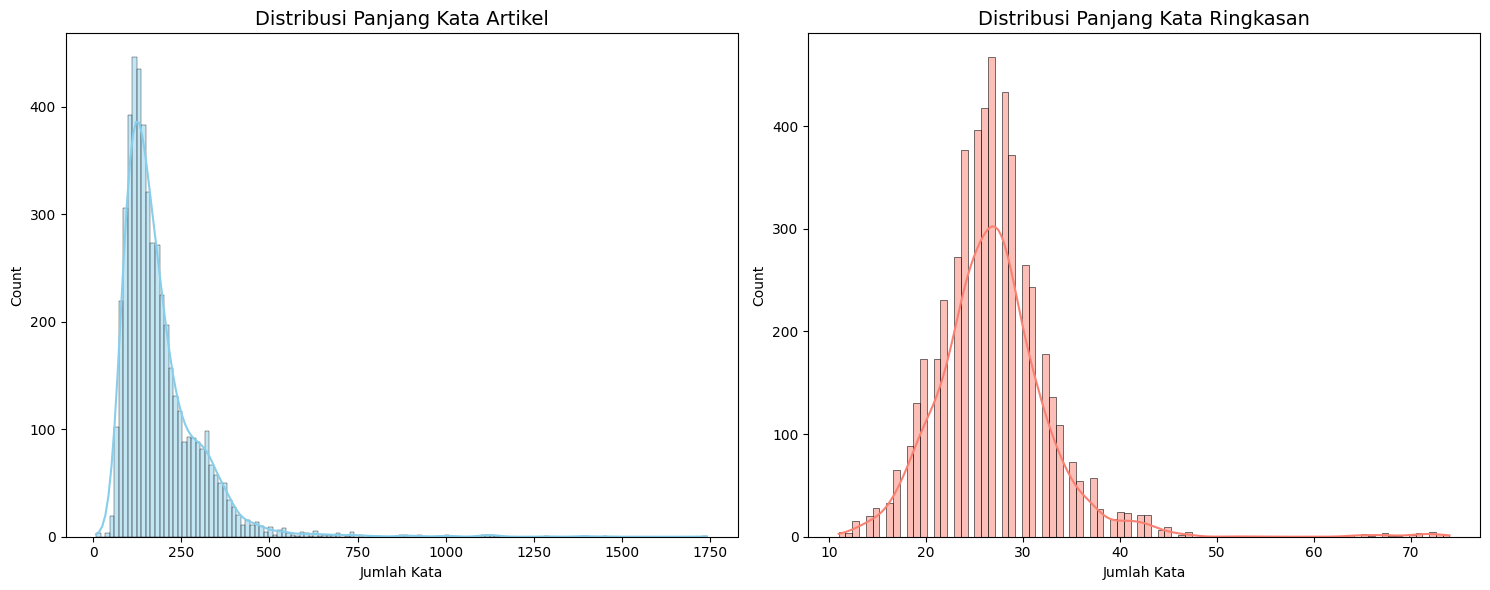

In [8]:
plt.figure(figsize=(15, 6))

# Histogram untuk Artikel
plt.subplot(1, 2, 1)
sns.histplot(df_train['article_wc'], kde=True, color='skyblue')
plt.title('Distribusi Panjang Kata Artikel', fontsize=14)
plt.xlabel('Jumlah Kata')

# Histogram untuk Summary
plt.subplot(1, 2, 2)
sns.histplot(df_train['summary_wc'], kde=True, color='salmon')
plt.title('Distribusi Panjang Kata Ringkasan', fontsize=14)
plt.xlabel('Jumlah Kata')

plt.tight_layout()
plt.show()

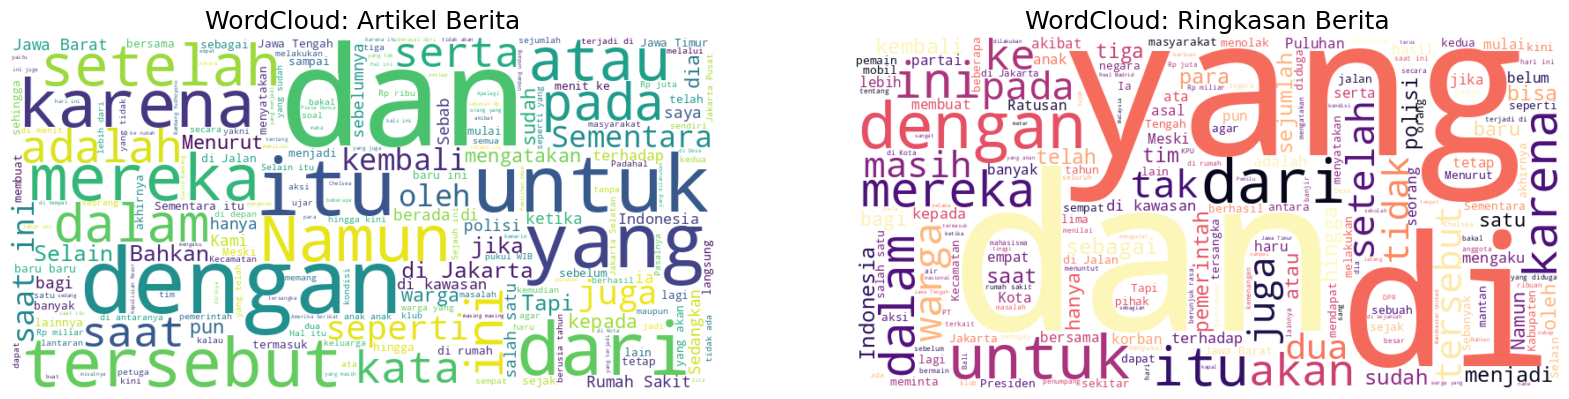

In [9]:
def generate_wc(data, title, cmap):
    text = " ".join(data.astype(str))
    wc = WordCloud(width=800, height=400, background_color='white', colormap=cmap).generate(text)
    plt.imshow(wc, interpolation='bilinear')
    plt.title(title, fontsize=18)
    plt.axis('off')

plt.figure(figsize=(20, 10))

# WordCloud Artikel
plt.subplot(1, 2, 1)
generate_wc(df_train['clean_article'], 'WordCloud: Artikel Berita', 'viridis')

# WordCloud Summary
plt.subplot(1, 2, 2)
generate_wc(df_train['clean_summary'], 'WordCloud: Ringkasan Berita', 'magma')

plt.show()

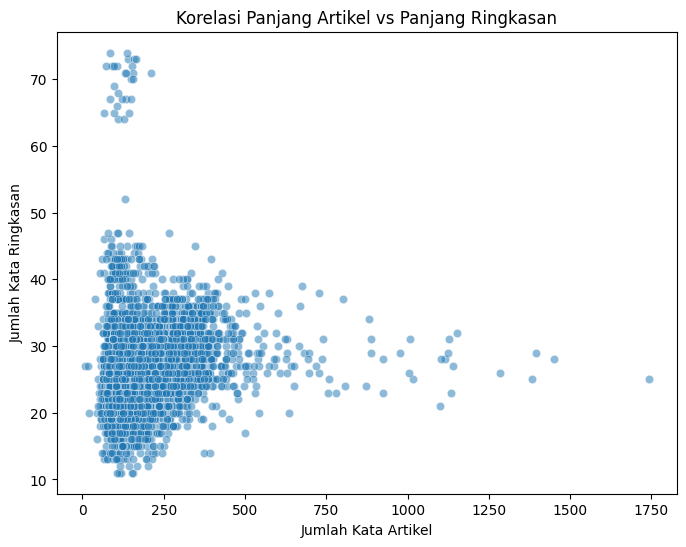

In [10]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='article_wc', y='summary_wc', data=df_train, alpha=0.5)
plt.title('Korelasi Panjang Artikel vs Panjang Ringkasan')
plt.xlabel('Jumlah Kata Artikel')
plt.ylabel('Jumlah Kata Ringkasan')
plt.show()